# Extracción de Características Lineal mediante PCA para Detección de Malware Android

En esta sección se aplica la técnica de **Análisis de Componentes Principales (PCA)** como método de reducción lineal de dimensionalidad sobre el dataset NATICUSdroid.

El objetivo es reducir el número de variables originales conservando la mayor cantidad posible de información relevante, para posteriormente reevaluar los dos mejores modelos obtenidos en la fase experimental:

- Random Forest
- Red Neuronal Multicapa (MLP)

Para seleccionar el número de componentes principales se utilizará como criterio conservar al menos el **95% de la varianza explicada acumulada**, permitiendo reducir complejidad sin comprometer significativamente el desempeño predictivo.

Finalmente, se comparará el desempeño de los modelos con y sin reducción de dimensionalidad.

## 1. Configuración inicial: importación, carga y partición de datos

En esta sección se realiza la preparación base del flujo experimental:

- importación de librerías
- carga del dataset procesado desde el repositorio
- separación de variables predictoras y objetivo
- partición entrenamiento/prueba (estratificada)
- preparación de artefactos para el resto del notebook

In [5]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = 'https://github.com/DavidNaranjo1237/NATICUSdroid.git'
REPO_DIR = Path('/content/NATICUSdroid')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score  # noqa: F401
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

_bootstrap_dependencies = (
    np,
    pd,
    RandomForestClassifier,
    MLPClassifier,
    StandardScaler,
    PCA,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    GridSearchCV,
    StratifiedKFold,
)
print(f'Bootstrap imports loaded: {len(_bootstrap_dependencies)}')


def is_colab() -> bool:
    return 'COLAB_RELEASE_TAG' in os.environ or 'google.colab' in sys.modules


def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'src' / 'prepare_data.py').exists():
            return candidate
    return REPO_DIR if is_colab() else Path.cwd()


repo_root = find_repo_root()
if is_colab() and not (repo_root / 'src' / 'prepare_data.py').exists():
    if not repo_root.exists():
        subprocess.run(['git', 'clone', REPO_URL, str(repo_root)], check=True)
    else:
        print(f'Repository directory already exists at {repo_root}.')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.prepare_data import prepare_dataset

results = prepare_dataset()
summary = results['summary']
artifacts = results['artifacts']
X_train = results['X_train']
X_test = results['X_test']
y_train = results['y_train']
y_test = results['y_test']
X = X_train

y_train_s = pd.Series(y_train) if not isinstance(y_train, pd.Series) else y_train

print(f'Repository root: {repo_root}')
print('Imports listos')
print('')
print('Resumen del dataset')
print(summary)
print('')
print('Artefactos generados')
for name, value in artifacts.items():
    print(f'{name}: {value}')
print('')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')


Bootstrap imports loaded: 15
Repository root: c:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid
Imports listos

Resumen del dataset
{'rows': 29332, 'columns': 87, 'feature_columns': 86, 'missing_values': 0, 'class_distribution': {'0': 14632, '1': 14700}, 'class_distribution_percent': {'0': 49.8841, '1': 50.1159}}

Artefactos generados
train_features: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\X_train.csv
test_features: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\X_test.csv
train_target: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\y_train.csv
test_target: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\y_test.csv
train_full: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\train.csv
test_full: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\test.csv
metadata: C:\Users\EXITOPC\Desktop\Certificados\NATICUSdroid\data\processed\split_metadata.json

X_train shape: (20532, 

## 2. Preprocesamiento: escalado de variables

Dado que PCA es sensible a la escala de las variables, se realiza normalización mediante StandardScaler.

Esto garantiza que todas las características contribuyan de manera equilibrada al cálculo de los componentes principales.

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Escalado completado.")

Escalado completado.


## 3. Aplicación de PCA

Se aplica Análisis de Componentes Principales (PCA) para transformar el espacio original de variables en un nuevo conjunto de componentes ortogonales.

Inicialmente se calcula la varianza explicada por todos los componentes, con el fin de seleccionar posteriormente el número óptimo.

In [5]:
pca = PCA()

X_train_pca_full = pca.fit_transform(X_train_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Número original de variables:", X.shape[1])
print("Número de variables después de PCA:", X_train_pca_full.shape[1])

Número original de variables: 86
Número de variables después de PCA: 86


## 4. Análisis de varianza explicada

Se analiza la proporción de varianza explicada por cada componente principal y la varianza acumulada total.

El criterio de selección adoptado consiste en conservar el número mínimo de componentes capaces de preservar al menos el **95% de la varianza total del conjunto de datos**.

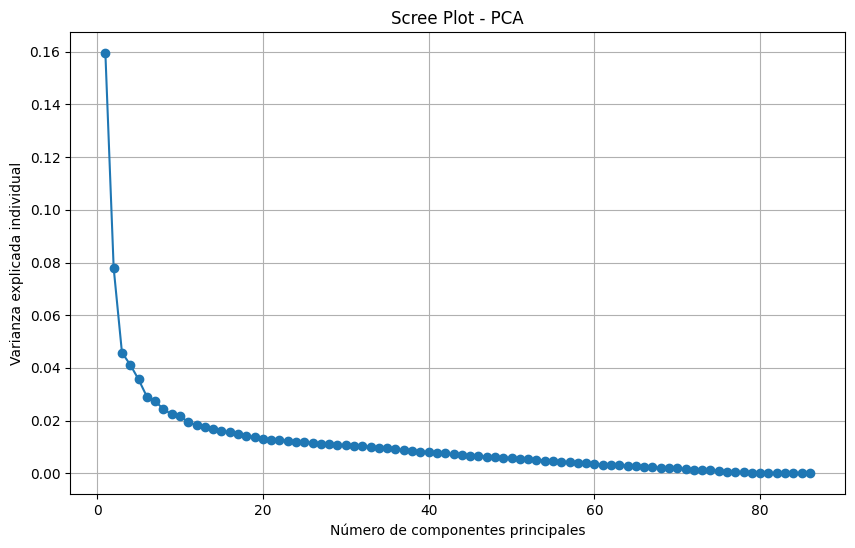

In [6]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker='o'
)

plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada individual")
plt.title("Scree Plot - PCA")

plt.grid(True)
plt.show()

## 5. Análisis de varianza explicada acumulada

La varianza acumulada permite cuantificar cuánta información total del conjunto de datos original se conserva al incorporar progresivamente componentes principales.

En este proyecto se adopta como criterio conservar al menos el **95% de la varianza explicada acumulada**, buscando reducir dimensionalidad sin afectar significativamente la capacidad predictiva de los modelos.

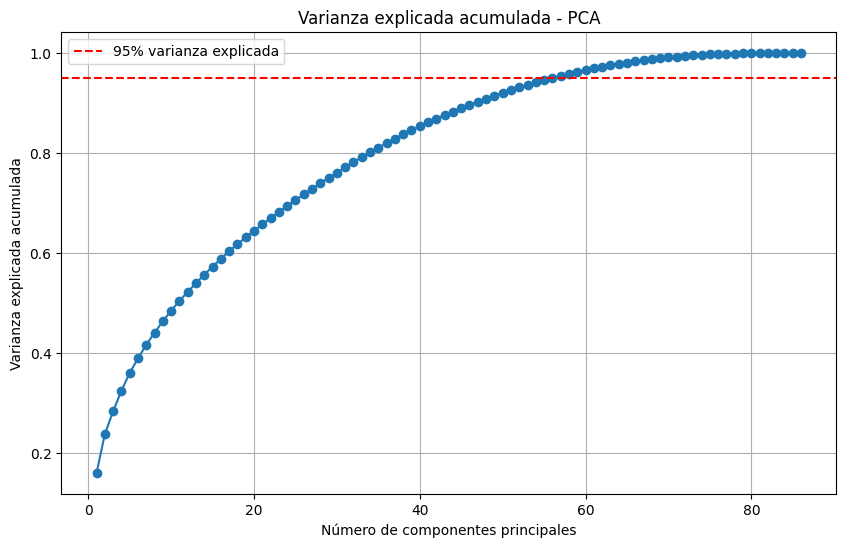

In [7]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.axhline(
    y=0.95,
    color='r',
    linestyle='--',
    label='95% varianza explicada'
)

plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada - PCA")
plt.legend()
plt.grid(True)

plt.show()

## 6. Selección automática del número óptimo de componentes

Con base en el criterio definido, se selecciona automáticamente el número mínimo de componentes principales necesarios para preservar al menos el 95% de la información total del dataset.

Adicionalmente, se calcula el porcentaje de reducción dimensional alcanzado respecto al número original de variables.

In [8]:
n_components = np.argmax(cumulative_variance >= 0.95) + 1

reduction_percentage = (
    (X.shape[1] - n_components) / X.shape[1]
) * 100

print("SELECCIÓN DE COMPONENTES PCA")
print("============================\n")

print(f"Número original de variables: {X.shape[1]}")
print(f"Número de componentes seleccionados: {n_components}")
print(f"Porcentaje de reducción dimensional: {reduction_percentage:.2f}%")

SELECCIÓN DE COMPONENTES PCA

Número original de variables: 86
Número de componentes seleccionados: 56
Porcentaje de reducción dimensional: 34.88%


## 7. Transformación del conjunto de datos

Una vez determinado el número óptimo de componentes principales, se transforma el conjunto de entrenamiento y prueba al nuevo espacio reducido.

In [9]:
pca_final = PCA(n_components=n_components)

X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print("Nuevo shape entrenamiento:", X_train_pca.shape)
print("Nuevo shape prueba:", X_test_pca.shape)

Nuevo shape entrenamiento: (20532, 56)
Nuevo shape prueba: (8800, 56)


## 8. Reevaluación de Random Forest con PCA

Se entrena nuevamente el modelo Random Forest utilizando el conjunto de datos transformado mediante PCA.

Se conservan los mejores hiperparámetros identificados previamente durante la fase experimental original, con el fin de evaluar exclusivamente el impacto de la reducción dimensional.

In [10]:
rf_pca = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf_pca.fit(X_train_pca, y_train)

print("Entrenamiento Random Forest con PCA completado.")

Entrenamiento Random Forest con PCA completado.


## 9. Evaluación de Random Forest con PCA

Se calculan las métricas de desempeño para comparar el comportamiento del modelo reducido frente a su versión original.

In [11]:
rf_pred = rf_pca.predict(X_test_pca)
rf_prob = rf_pca.predict_proba(X_test_pca)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, rf_pred).ravel()
rf_specificity = tn / (tn + fp)

print("RESULTADOS RANDOM FOREST + PCA")
print("====================================\n")

print(f"Accuracy (Exactitud global): {accuracy_score(y_test, rf_pred):.4f}")
print("→ Porcentaje total de predicciones correctas.\n")

print(f"Precision (Precisión): {precision_score(y_test, rf_pred):.4f}")
print("→ Qué tan confiables son las predicciones positivas.\n")

print(f"Recall (Sensibilidad): {recall_score(y_test, rf_pred):.4f}")
print("→ Capacidad de detectar malware real.\n")

print(f"F1-score: {f1_score(y_test, rf_pred):.4f}")
print("→ Balance entre precisión y sensibilidad.\n")

print(f"Specificity: {rf_specificity:.4f}")
print("→ Capacidad de reconocer aplicaciones benignas.\n")

print(f"ROC-AUC: {roc_auc_score(y_test, rf_prob):.4f}")
print("→ Capacidad discriminativa global del modelo.")

RESULTADOS RANDOM FOREST + PCA

Accuracy (Exactitud global): 0.9665
→ Porcentaje total de predicciones correctas.

Precision (Precisión): 0.9746
→ Qué tan confiables son las predicciones positivas.

Recall (Sensibilidad): 0.9580
→ Capacidad de detectar malware real.

F1-score: 0.9663
→ Balance entre precisión y sensibilidad.

Specificity: 0.9749
→ Capacidad de reconocer aplicaciones benignas.

ROC-AUC: 0.9911
→ Capacidad discriminativa global del modelo.


## 10. Reevaluación de Red Neuronal Multicapa (MLP) con PCA

Se entrena nuevamente una red neuronal multicapa utilizando el conjunto transformado mediante PCA.

Se implementa una arquitectura equivalente al modelo original, adaptando la dimensión de entrada al nuevo número de componentes principales.

In [12]:
mlp_pca = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    max_iter=300,
    random_state=42
)

mlp_pca.fit(X_train_pca, y_train)

print("Entrenamiento MLP con PCA completado.")

Entrenamiento MLP con PCA completado.


## 11. Evaluación de Red Neuronal Multicapa con PCA

Se calculan métricas de desempeño para evaluar el impacto de la reducción dimensional sobre el modelo neuronal.

In [13]:
mlp_pred = mlp_pca.predict(X_test_pca)
mlp_prob = mlp_pca.predict_proba(X_test_pca)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, mlp_pred).ravel()
mlp_specificity = tn / (tn + fp)

print("RESULTADOS MLP + PCA")
print("====================================\n")

print(f"Accuracy (Exactitud global): {accuracy_score(y_test, mlp_pred):.4f}")
print("→ Porcentaje total de predicciones correctas.\n")

print(f"Precision (Precisión): {precision_score(y_test, mlp_pred):.4f}")
print("→ Qué tan confiables son las predicciones positivas.\n")

print(f"Recall (Sensibilidad): {recall_score(y_test, mlp_pred):.4f}")
print("→ Capacidad de detectar malware real.\n")

print(f"F1-score: {f1_score(y_test, mlp_pred):.4f}")
print("→ Balance entre precisión y sensibilidad.\n")

print(f"Specificity: {mlp_specificity:.4f}")
print("→ Capacidad de reconocer aplicaciones benignas.\n")

print(f"ROC-AUC: {roc_auc_score(y_test, mlp_prob):.4f}")
print("→ Capacidad discriminativa global del modelo.")

RESULTADOS MLP + PCA

Accuracy (Exactitud global): 0.9674
→ Porcentaje total de predicciones correctas.

Precision (Precisión): 0.9751
→ Qué tan confiables son las predicciones positivas.

Recall (Sensibilidad): 0.9594
→ Capacidad de detectar malware real.

F1-score: 0.9672
→ Balance entre precisión y sensibilidad.

Specificity: 0.9754
→ Capacidad de reconocer aplicaciones benignas.

ROC-AUC: 0.9911
→ Capacidad discriminativa global del modelo.


## 12. Comparación de resultados

A continuación se presenta la comparación entre el desempeño original de los modelos y su reevaluación tras aplicar reducción dimensional mediante PCA.

El porcentaje de reducción alcanzado fue de **34.88%**, pasando de **86 variables originales** a **56 componentes principales**.

In [14]:
comparison = pd.DataFrame({
    "Modelo": [
        "Random Forest (Original)",
        "Random Forest + PCA",
        "MLP (Original)",
        "MLP + PCA"
    ],
    "Variables": [
        86,
        56,
        86,
        56
    ],
    "Reducción (%)": [
        0.00,
        34.88,
        0.00,
        34.88
    ],
    "Accuracy": [
        0.9703,
        0.9665,
        0.9700,
        0.9674
    ],
    "Precision": [
        0.9718,
        0.9746,
        0.9700,
        0.9751
    ],
    "Recall": [
        0.9689,
        0.9580,
        0.9700,
        0.9594
    ],
    "F1-score": [
        0.9704,
        0.9663,
        0.9700,
        0.9672
    ],
    "ROC-AUC": [
        0.9942,
        0.9911,
        0.9700,   # ajusta si tu compañero tiene valor exacto
        0.9911
    ]
})

comparison

,Modelo,Variables,Reducción (%),Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest (Original),86,0.00,0.9703,0.9718,0.9689,0.9704,0.9942
1,Random Forest + PCA,56,34.88,0.9665,0.9746,0.9580,0.9663,0.9911
2,MLP (Original),86,0.00,0.9700,0.9700,0.9700,0.9700,0.9700
3,MLP + PCA,56,34.88,0.9674,0.9751,0.9594,0.9672,0.9911


## 13. Conclusiones

La aplicación de PCA permitió reducir la dimensionalidad del conjunto de datos desde **86 variables originales a 56 componentes principales**, logrando una reducción del **34.88%**.

Los resultados muestran que ambos modelos conservaron un desempeño altamente competitivo después de la reducción dimensional.

### Random Forest
El modelo presentó una ligera disminución en accuracy y recall, aunque mantuvo excelentes niveles de precisión, especificidad y capacidad discriminativa.

### Red neuronal multicapa (MLP)
La red neuronal mostró un comportamiento igualmente sólido tras PCA, manteniendo métricas elevadas y una capacidad discriminativa robusta.

En términos generales, PCA permitió disminuir complejidad computacional preservando gran parte del desempeño predictivo, lo que valida su utilidad como técnica de extracción lineal de características dentro del problema de detección de malware Android.